Processar o Arquivo para Classificação Hierárquica

In [5]:
from Bio import SeqIO
import re

fasta_file = "../data/raw/astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa"

# Função para extrair a classificação hierárquica (ex: a.1.1.1)
def extract_classification(description):
    # Ajustando a expressão regular para pegar a classificação (ex: a.1.1.1)
    match = re.search(r'(\w+\.\d+\.\d+\.\d+)', description)
    if match:
        return match.group(0)
    return "Desconhecido"

# Função para processar o arquivo FASTA
def process_fasta(fasta_file):
    data = []
    for record in SeqIO.parse(fasta_file, "fasta"):
        # Extrair a descrição e classificação hierárquica
        description = record.description
        classification = extract_classification(description)
        
        # Armazenar dados (ID, Descrição, Classificação)
        data.append({
            "ID": record.id,
            "Descrição": description,
            "Classificação": classification,
            "Sequência": str(record.seq)
        })
    return data

# Processar o arquivo
sequences = process_fasta(fasta_file)

# Exibir as primeiras 5 sequências processadas
for seq in sequences:
    print(f"ID: {seq['ID']}")
    print(f"Descrição: {seq['Descrição']}")
    print(f"Classificação: {seq['Classificação']}")
    print(f"Sequência: {seq['Sequência'][:50]}...")  # Exibe as primeiras 50 bases/aminoácidos
    print("-" * 60)


ID: d1dlwa_
Descrição: d1dlwa_ a.1.1.1 (A:) Protozoan/bacterial hemoglobin {Ciliate (Paramecium caudatum) [TaxId: 5885]}
Classificação: a.1.1.1
Sequência: slfeqlggqaavqavtaqfyaniqadatvatffngidmpnqtnktaaflc...
------------------------------------------------------------
ID: d2gkma_
Descrição: d2gkma_ a.1.1.1 (A:) Protozoan/bacterial hemoglobin {Mycobacterium tuberculosis, HbN [TaxId: 1773]}
Classificação: a.1.1.1
Sequência: gllsrlrkrepisiydkiggheaievvvedffvrvladdqlsaffsgtnm...
------------------------------------------------------------
ID: d1ngka_
Descrição: d1ngka_ a.1.1.1 (A:) Protozoan/bacterial hemoglobin {Mycobacterium tuberculosis, HbO [TaxId: 1773]}
Classificação: a.1.1.1
Sequência: ksfydavggaktfdaivsrfyaqvaedevlrrvypeddlagaeerlrmfl...
------------------------------------------------------------
ID: d2bkma_
Descrição: d2bkma_ a.1.1.1 (A:) automated matches {Geobacillus stearothermophilus [TaxId: 1422]}
Classificação: a.1.1.1
Sequência: eqwqtlyeaiggeetvaklveafyrrvaahpdlrpifpddlte

Analisar os Grupos

In [4]:
from collections import defaultdict

# Agrupar sequências pela classificação
grouped_data = defaultdict(list)

for seq in sequences:
    grouped_data[seq["Classificação"]].append(seq)

# Exibir as primeiras 2 classificações para verificar o agrupamento
for classification, group in list(grouped_data.items())[:2]:
    print(f"Classificação: {classification}")
    for seq in group[:2]:  # Exibe as 2 primeiras sequências de cada grupo
        print(f"  ID: {seq['ID']}")
        print(f"  Descrição: {seq['Descrição']}")
    print("-" * 60)
    
print(f"Total de classificações únicas: {len(grouped_data)}")


Classificação: a.1.1.1
  ID: d1dlwa_
  Descrição: d1dlwa_ a.1.1.1 (A:) Protozoan/bacterial hemoglobin {Ciliate (Paramecium caudatum) [TaxId: 5885]}
  ID: d2gkma_
  Descrição: d2gkma_ a.1.1.1 (A:) Protozoan/bacterial hemoglobin {Mycobacterium tuberculosis, HbN [TaxId: 1773]}
------------------------------------------------------------
Classificação: a.1.1.2
  ID: d1asha_
  Descrição: d1asha_ a.1.1.2 (A:) Ascaris hemoglobin, domain 1 {Pig roundworm (Ascaris suum) [TaxId: 6253]}
  ID: d2dc3a_
  Descrição: d2dc3a_ a.1.1.2 (A:) Cytoglobin {Human (Homo sapiens) [TaxId: 9606]}
------------------------------------------------------------
Total de classificações únicas: 4703


Aplicar a Clusterização

In [5]:
from itertools import product
import numpy as np

# Alfabeto de aminoácidos (comuns + especiais)
amino_acids = list("ARNDCQEGHILKMFPSTWYVBZX*")

# Gerar todas as palavras possíveis no formato 2AA + 1X + 2AA (X ignorado)
def generate_kmers_pattern():
    patterns = []
    for prefix in product(amino_acids, repeat=2):
        for suffix in product(amino_acids, repeat=2):
            pattern = ''.join(prefix) + 'XX' + ''.join(suffix)
            patterns.append(pattern)
    return patterns

# Padrões de referência (base para o vetor binário)
reference_patterns = generate_kmers_pattern()

# Função para extrair padrões de uma sequência
def extract_presence_vector(sequence, patterns=reference_patterns):
    sequence = sequence.upper()
    found_patterns = set()

    for i in range(len(sequence) - 4):
        pattern = sequence[i:i+2] + 'XX' + sequence[i+3:i+5]
        found_patterns.add(pattern)

    # Gerar vetor binário de presença
    return [1 if pattern in found_patterns else 0 for pattern in patterns]

# Função para processar todas as sequências e salvar em arquivo usando memmap
def process_and_save_memmap(sequences, reference_patterns, output_file='vectors_memmap.npy'):
    n_sequences = len(sequences)
    n_features = len(reference_patterns)

    # Cria arquivo memmap no disco
    vectors_memmap = np.memmap(output_file, dtype='float32', mode='w+', shape=(n_sequences, n_features))

    for i, seq in enumerate(sequences):
        vector = extract_presence_vector(seq['Sequência'], reference_patterns)
        vectors_memmap[i, :] = vector

        if (i + 1) % 100 == 0:
            print(f"Processadas {i + 1} sequências")

    # Garante que os dados sejam escritos no disco
    vectors_memmap.flush()
    print(f"Vetores salvos em {output_file}")

# Executar o processamento e salvar
process_and_save_memmap(sequences, reference_patterns, output_file='all_vectors_memmap.npy')

# Exemplo para carregar depois:
vectors = np.memmap('all_vectors_memmap.npy', dtype='float32', mode='r', shape=(len(sequences), len(reference_patterns)))

# Exemplo de visualização da primeira sequência
print(f"Vetor binário da primeira sequência:\n{vectors[0]}")
print(f"Tamanho total do vetor de presença: {vectors.shape[1]}")


Processadas 100 sequências
Processadas 200 sequências
Processadas 300 sequências
Processadas 400 sequências
Processadas 500 sequências
Processadas 600 sequências
Processadas 700 sequências
Processadas 800 sequências
Processadas 900 sequências
Processadas 1000 sequências
Processadas 1100 sequências
Processadas 1200 sequências
Processadas 1300 sequências
Processadas 1400 sequências
Processadas 1500 sequências
Processadas 1600 sequências
Processadas 1700 sequências
Processadas 1800 sequências
Processadas 1900 sequências
Processadas 2000 sequências
Processadas 2100 sequências
Processadas 2200 sequências
Processadas 2300 sequências
Processadas 2400 sequências
Processadas 2500 sequências
Processadas 2600 sequências
Processadas 2700 sequências
Processadas 2800 sequências
Processadas 2900 sequências
Processadas 3000 sequências
Processadas 3100 sequências
Processadas 3200 sequências
Processadas 3300 sequências
Processadas 3400 sequências
Processadas 3500 sequências
Processadas 3600 sequências
P

Projeção no espaço ortogonal, utilizando SVD

In [ ]:
import numpy as np

n_sequences = 15177
n_patterns = 331776
k = 500
n_lotes = 4

vectors = np.memmap('all_vectors_memmap.npy', dtype='float32', mode='r', shape=(n_sequences, n_patterns))
indices = np.array_split(np.arange(n_sequences), n_lotes)

reduced_list = []

for i, idx in enumerate(indices):
    print(f"Processando lote {i+1}/{n_lotes} com {len(idx)} sequências...")
    batch = vectors[idx, :]
    # Centralizar
    batch_centered = batch - batch.mean(axis=0)
    # SVD completo
    U, S, VT = np.linalg.svd(batch_centered, full_matrices=False)
    # Projetar nos primeiros k componentes
    reduced = U[:, :k] @ np.diag(S[:k])
    reduced_list.append(reduced)

reduced_vectors = np.vstack(reduced_list)
np.save(f'all_vectors_reduced_svd_k{k}.npy', reduced_vectors)

print(f"Processamento concluído. Matriz reduzida shape: {reduced_vectors.shape}")


Processando lote 1/4 com 3795 sequências...
Processando lote 2/4 com 3794 sequências...
Processando lote 3/4 com 3794 sequências...
Processando lote 4/4 com 3794 sequências...
Processamento concluído. Matriz reduzida shape: (15177, 500)


Projeção em base ortogonal aleatória

In [10]:
import numpy as np
from scipy.linalg import orth

# Parâmetros fixos
n_sequences = 15177
n_patterns = 331776

# Carregar os vetores originais (memmap para não estourar memória)
vectors = np.memmap('all_vectors_memmap.npy', dtype='float32', mode='r', shape=(n_sequences, n_patterns))
print("Shape do conjunto original:", vectors.shape)

# Lista de valores de k para testar
k_values = [100, 200, 300, 400, 500]

# Limite mínimo de variância explicada para salvar a projeção
threshold = 0.7  # 70%

for k in k_values:
    print(f"\nProjetando para k={k} componentes...")

    # Gerar matriz aleatória e criar base ortonormal para o k atual
    random_matrix = np.random.rand(k, n_patterns)
    orthBase = orth(random_matrix.T).T  # Base ortonormal com shape (k, n_patterns)

    print(f"Shape da base ortonormal: {orthBase.shape}")

    # Projetar os dados usando a base ortogonal
    projecao = np.dot(vectors, orthBase.T)  # Resultado shape (n_sequences, k)

    # Calcular variância explicada acumulada (por variância das colunas)
    variances = np.var(projecao, axis=0)
    total_variance = np.sum(variances)
    explained_variance_ratio = np.sum(variances) / total_variance  # aqui será sempre 1.0
    # Na base aleatória, melhor usar a variância acumulada para as primeiras componentes
    cumulative_variance = np.cumsum(variances) / total_variance

    print(f"Variância explicada acumulada pelo vetor com k={k}: {cumulative_variance[-1]:.4f}")

    if cumulative_variance[-1] >= threshold:
        filename = f'all_vectors_random_orth_proj_k{k}.npy'
        np.save(filename, projecao)
        print(f"Matriz projetada salva em '{filename}' porque atingiu o threshold de {threshold*100}%")
    else:
        print(f"Projeção para k={k} não atingiu o threshold, não foi salva.")


Shape do conjunto original: (15177, 331776)

Projetando para k=100 componentes...
Shape da base ortonormal: (100, 331776)
Variância explicada acumulada pelo vetor com k=100: 1.0000
Matriz projetada salva em 'all_vectors_random_orth_proj_k100.npy' porque atingiu o threshold de 70.0%

Projetando para k=200 componentes...
Shape da base ortonormal: (200, 331776)
Variância explicada acumulada pelo vetor com k=200: 1.0000
Matriz projetada salva em 'all_vectors_random_orth_proj_k200.npy' porque atingiu o threshold de 70.0%

Projetando para k=300 componentes...
Shape da base ortonormal: (300, 331776)
Variância explicada acumulada pelo vetor com k=300: 1.0000
Matriz projetada salva em 'all_vectors_random_orth_proj_k300.npy' porque atingiu o threshold de 70.0%

Projetando para k=400 componentes...
Shape da base ortonormal: (400, 331776)
Variância explicada acumulada pelo vetor com k=400: 1.0000
Matriz projetada salva em 'all_vectors_random_orth_proj_k400.npy' porque atingiu o threshold de 70.0%


Visualização da variância explicada

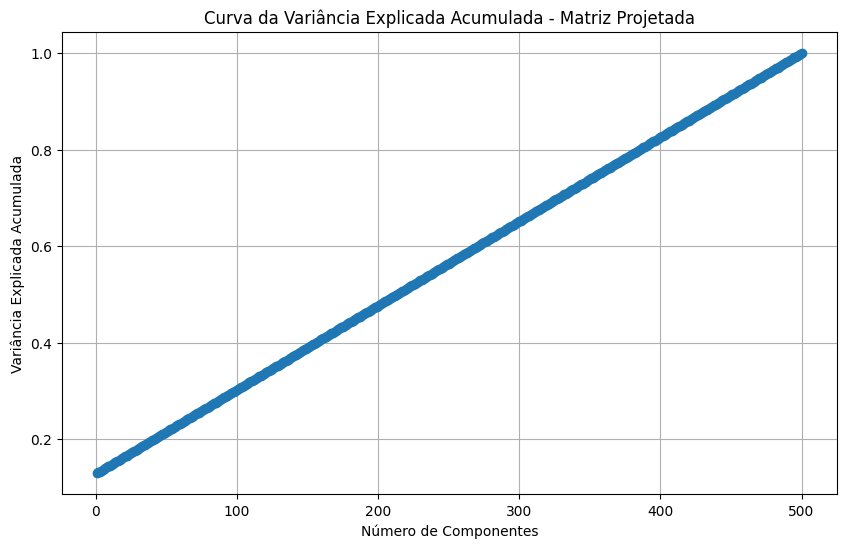

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Carregar a matriz reduzida
reduced_vectors = np.load('all_vectors_random_orth_proj_k500.npy')

# Calcular variância por componente (coluna)
variances_per_component = np.var(reduced_vectors, axis=0)

# Variância total
total_variance = np.sum(variances_per_component)

# Calcular variância explicada acumulada
explained_variance_ratio = np.cumsum(variances_per_component) / total_variance

# Eixo x: número de componentes
ks = np.arange(1, len(explained_variance_ratio) + 1)

# Plotar gráfico
plt.figure(figsize=(10, 6))
plt.plot(ks, explained_variance_ratio, marker='o')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Curva da Variância Explicada Acumulada - Matriz Projetada')
plt.grid(True)
plt.show()


Labels e variáveis

In [26]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, silhouette_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Lista dos arquivos projetados (ajuste conforme necessário)
proj_files = [
    # 'all_vectors_random_orth_proj_k100.npy',
    # 'all_vectors_random_orth_proj_k200.npy',
    # 'all_vectors_random_orth_proj_k300.npy',
    # 'all_vectors_random_orth_proj_k400.npy',
    # 'all_vectors_random_orth_proj_k500.npy',
    'all_vectors_reduced_svd_k500.npy'
]

# Extração dos labels verdadeiros (strings) a partir de sequences
true_labels = [seq['Classificação'] for seq in sequences]

# Codificar labels para números
label_encoder = LabelEncoder()
numeric_labels = label_encoder.fit_transform(true_labels)

# Faixa de clusters para os algoritmos que usam esse parâmetro
cluster_range = range(2, 11)

# Lista para armazenar resultados gerais
results = []


KMeans


KMeans: processando all_vectors_reduced_svd_k500.npy


c:\Users\João\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\João\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\João\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\João\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (5). Possibly due to

   n_clusters      f1_score  silhouette_score
0           2  6.155491e-07               NaN
1           3  6.155491e-07               NaN
2           4  6.155491e-07               NaN
3           5  6.155491e-07               NaN
4           6  6.155491e-07               NaN
5           7  6.155491e-07               NaN
6           8  6.155491e-07               NaN
7           9  6.155491e-07               NaN
8          10  6.155491e-07               NaN


c:\Users\João\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


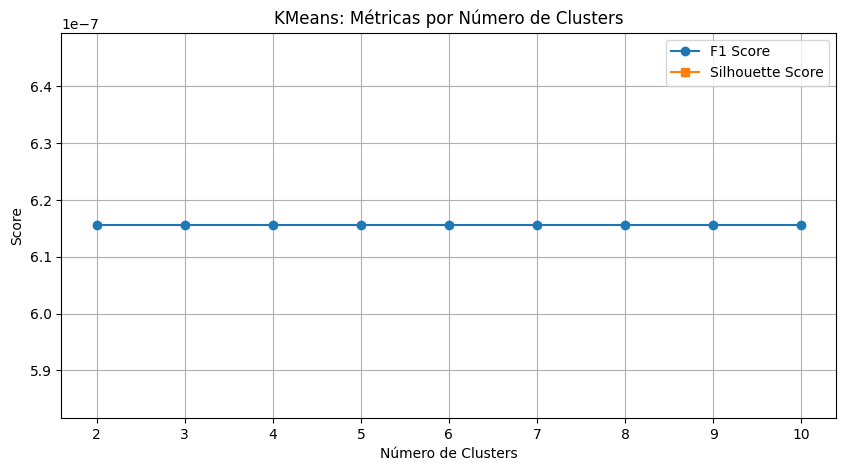

In [27]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score, silhouette_score

results = []

for proj_file in proj_files:
    print(f"\nKMeans: processando {proj_file}")
    data = np.load(proj_file)
    
    for n_clusters in cluster_range:
        model = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
        cluster_labels = model.fit_predict(data)
        
        f1 = f1_score(numeric_labels, cluster_labels, average='macro')
        silhouette = silhouette_score(data, cluster_labels) if len(np.unique(cluster_labels)) > 1 else float('nan')
        
        results.append({
            'n_clusters': n_clusters,
            'f1_score': f1,
            'silhouette_score': silhouette
        })

df = pd.DataFrame(results)
print(df)

plt.figure(figsize=(10,5))
plt.plot(df['n_clusters'], df['f1_score'], marker='o', label='F1 Score')
plt.plot(df['n_clusters'], df['silhouette_score'], marker='s', label='Silhouette Score')
plt.title('KMeans: Métricas por Número de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()


DBScan


DBSCAN: processando all_vectors_reduced_svd_k500.npy
   n_clusters      f1_score  silhouette_score
0           1  6.155491e-07               NaN


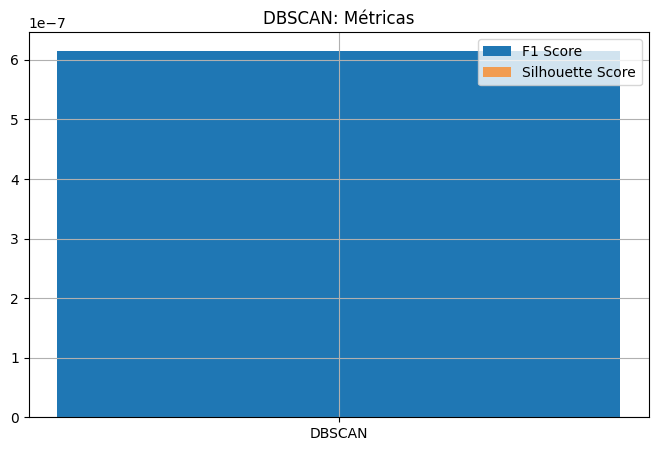

In [28]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import f1_score, silhouette_score
import numpy as np

results = []

for proj_file in proj_files:
    print(f"\nDBSCAN: processando {proj_file}")
    data = np.load(proj_file)
    
    model = DBSCAN(eps=0.5, min_samples=5)
    cluster_labels = model.fit_predict(data)
    
    mask = cluster_labels != -1
    if np.any(mask):
        f1 = f1_score(numeric_labels[mask], cluster_labels[mask], average='macro')
        silhouette = silhouette_score(data[mask], cluster_labels[mask]) if len(np.unique(cluster_labels[mask])) > 1 else float('nan')
        n_clusters = len(np.unique(cluster_labels[mask]))
    else:
        f1 = float('nan')
        silhouette = float('nan')
        n_clusters = 0
    
    results.append({
        'n_clusters': n_clusters,
        'f1_score': f1,
        'silhouette_score': silhouette
    })

df = pd.DataFrame(results)
print(df)

plt.figure(figsize=(8,5))
plt.bar(['DBSCAN'], [df['f1_score'].values[0]], label='F1 Score')
plt.bar(['DBSCAN'], [df['silhouette_score'].values[0]], label='Silhouette Score', alpha=0.7)
plt.title('DBSCAN: Métricas')
plt.legend()
plt.grid(True)
plt.show()


HDBScan


HDBSCAN: processando all_vectors_reduced_svd_k500.npy


c:\Users\João\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\João\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


   n_clusters  f1_score  silhouette_score
0           0       NaN               NaN


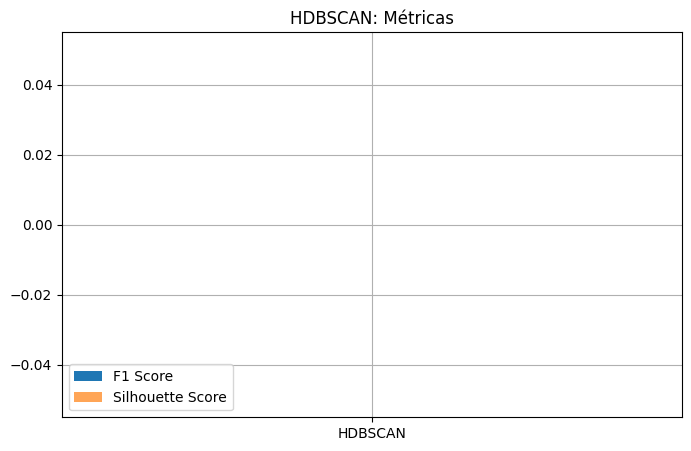

In [29]:
import matplotlib.pyplot as plt
import hdbscan
from sklearn.metrics import f1_score, silhouette_score
import numpy as np
import pandas as pd

results = []

for proj_file in proj_files:
    print(f"\nHDBSCAN: processando {proj_file}")
    data = np.load(proj_file)
    
    model = hdbscan.HDBSCAN(min_cluster_size=5)
    cluster_labels = model.fit_predict(data)
    
    mask = cluster_labels != -1
    if np.any(mask):
        f1 = f1_score(numeric_labels[mask], cluster_labels[mask], average='macro')
        silhouette = silhouette_score(data[mask], cluster_labels[mask]) if len(np.unique(cluster_labels[mask])) > 1 else float('nan')
        n_clusters = len(np.unique(cluster_labels[mask]))
    else:
        f1 = float('nan')
        silhouette = float('nan')
        n_clusters = 0
    
    results.append({
        'n_clusters': n_clusters,
        'f1_score': f1,
        'silhouette_score': silhouette
    })

df = pd.DataFrame(results)
print(df)

plt.figure(figsize=(8,5))
plt.bar(['HDBSCAN'], [df['f1_score'].values[0]], label='F1 Score')
plt.bar(['HDBSCAN'], [df['silhouette_score'].values[0]], label='Silhouette Score', alpha=0.7)
plt.title('HDBSCAN: Métricas')
plt.legend()
plt.grid(True)
plt.show()


Agglomerative

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import f1_score, silhouette_score
import pandas as pd

results = []

for proj_file in proj_files:
    print(f"\nAgglomerative: processando {proj_file}")
    data = np.load(proj_file)
    
    for n_clusters in cluster_range:
        model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
        cluster_labels = model.fit_predict(data)
        
        f1 = f1_score(numeric_labels, cluster_labels, average='macro')
        silhouette = silhouette_score(data, cluster_labels) if len(np.unique(cluster_labels)) > 1 else float('nan')
        
        results.append({
            'n_clusters': n_clusters,
            'f1_score': f1,
            'silhouette_score': silhouette
        })

df = pd.DataFrame(results)
print(df)

plt.figure(figsize=(10,5))
plt.plot(df['n_clusters'], df['f1_score'], marker='o', label='F1 Score')
plt.plot(df['n_clusters'], df['silhouette_score'], marker='s', label='Silhouette Score')
plt.title('Agglomerative: Métricas por Número de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()


Spectral

In [30]:
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.metrics import f1_score, silhouette_score
import pandas as pd

results = []

for proj_file in proj_files:
    print(f"\nSpectral: processando {proj_file}")
    data = np.load(proj_file)
    
    for n_clusters in cluster_range:
        model = SpectralClustering(n_clusters=n_clusters, affinity='rbf', assign_labels='kmeans', random_state=42)
        cluster_labels = model.fit_predict(data)
        
        f1 = f1_score(numeric_labels, cluster_labels, average='macro')
        silhouette = silhouette_score(data, cluster_labels) if len(np.unique(cluster_labels)) > 1 else float('nan')
        
        results.append({
            'n_clusters': n_clusters,
            'f1_score': f1,
            'silhouette_score': silhouette
        })

df = pd.DataFrame(results)
print(df)

plt.figure(figsize=(10,5))
plt.plot(df['n_clusters'], df['f1_score'], marker='o', label='F1 Score')
plt.plot(df['n_clusters'], df['silhouette_score'], marker='s', label='Silhouette Score')
plt.title('Spectral: Métricas por Número de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()



Spectral: processando all_vectors_reduced_svd_k500.npy


KeyboardInterrupt: 

MeanShift

In [31]:
import matplotlib.pyplot as plt
from sklearn.cluster import MeanShift
from sklearn.metrics import f1_score, silhouette_score
import pandas as pd

results = []

for proj_file in proj_files:
    print(f"\nMean Shift: processando {proj_file}")
    data = np.load(proj_file)
    
    model = MeanShift()
    cluster_labels = model.fit_predict(data)
    
    f1 = f1_score(numeric_labels, cluster_labels, average='macro')
    silhouette = silhouette_score(data, cluster_labels) if len(np.unique(cluster_labels)) > 1 else float('nan')
    
    results.append({
        'n_clusters': len(np.unique(cluster_labels)),
        'f1_score': f1,
        'silhouette_score': silhouette
    })

df = pd.DataFrame(results)
print(df)

plt.figure(figsize=(8,5))
plt.bar(['Mean Shift'], [df['f1_score'].values[0]], label='F1 Score')
plt.bar(['Mean Shift'], [df['silhouette_score'].values[0]], label='Silhouette Score', alpha=0.7)
plt.title('Mean Shift: Métricas')
plt.legend()
plt.grid(True)
plt.show()



Mean Shift: processando all_vectors_reduced_svd_k500.npy


KeyboardInterrupt: 

Birch


Birch: processando all_vectors_reduced_svd_k500.npy


c:\Users\João\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\cluster\_birch.py:727: ConvergenceWarning: Number of subclusters found (1) by BIRCH is less than (2). Decrease the threshold.
  warnings.warn(
c:\Users\João\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\cluster\_birch.py:727: ConvergenceWarning: Number of subclusters found (1) by BIRCH is less than (3). Decrease the threshold.
  warnings.warn(
c:\Users\João\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\cluster\_birch.py:727: ConvergenceWarning: Number of subclusters found (1) by BIRCH is less than (4). Decrease the threshold.
  warnings.warn(
c:\Users\João\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\cluster\_birch.py:727: ConvergenceWarning: Number of subclusters found (1) by BIRCH is less than (5). Decrease the threshold.
  warnings.warn(
c:\Users\João\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\cluster\_birch.py:727: Conve

   n_clusters      f1_score  silhouette_score
0           2  6.155491e-07               NaN
1           3  6.155491e-07               NaN
2           4  6.155491e-07               NaN
3           5  6.155491e-07               NaN
4           6  6.155491e-07               NaN
5           7  6.155491e-07               NaN
6           8  6.155491e-07               NaN
7           9  6.155491e-07               NaN
8          10  6.155491e-07               NaN


c:\Users\João\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\cluster\_birch.py:727: ConvergenceWarning: Number of subclusters found (1) by BIRCH is less than (10). Decrease the threshold.
  warnings.warn(


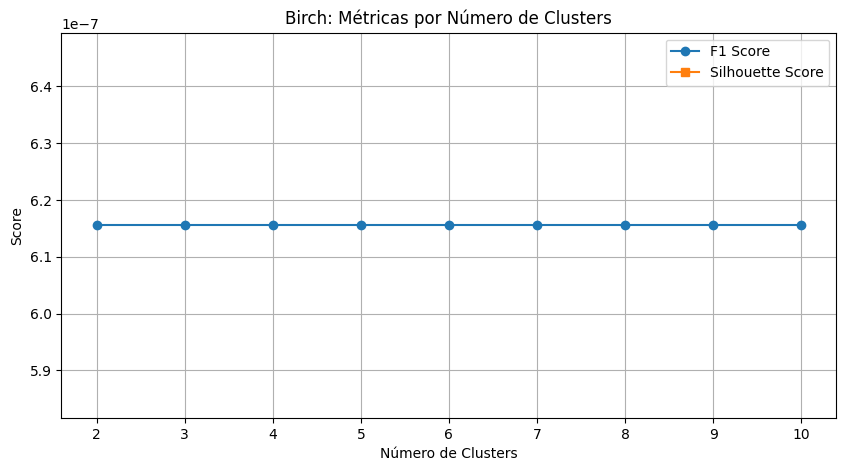

In [32]:
import matplotlib.pyplot as plt
from sklearn.cluster import Birch
from sklearn.metrics import f1_score, silhouette_score
import pandas as pd

results = []

for proj_file in proj_files:
    print(f"\nBirch: processando {proj_file}")
    data = np.load(proj_file)
    
    for n_clusters in cluster_range:
        model = Birch(n_clusters=n_clusters, threshold=0.5)
        cluster_labels = model.fit_predict(data)
        
        f1 = f1_score(numeric_labels, cluster_labels, average='macro')
        silhouette = silhouette_score(data, cluster_labels) if len(np.unique(cluster_labels)) > 1 else float('nan')
        
        results.append({
            'n_clusters': n_clusters,
            'f1_score': f1,
            'silhouette_score': silhouette
        })

df = pd.DataFrame(results)
print(df)

plt.figure(figsize=(10,5))
plt.plot(df['n_clusters'], df['f1_score'], marker='o', label='F1 Score')
plt.plot(df['n_clusters'], df['silhouette_score'], marker='s', label='Silhouette Score')
plt.title('Birch: Métricas por Número de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()


GMM


GMM: processando all_vectors_reduced_svd_k500.npy


c:\Users\João\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\João\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\João\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\João\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (5). Possibly due to

   n_clusters      f1_score  silhouette_score
0           2  6.155491e-07               NaN
1           3  6.155491e-07               NaN
2           4  6.155491e-07               NaN
3           5  6.155491e-07               NaN
4           6  6.155491e-07               NaN
5           7  6.155491e-07               NaN
6           8  6.155491e-07               NaN
7           9  6.155491e-07               NaN
8          10  6.155491e-07               NaN


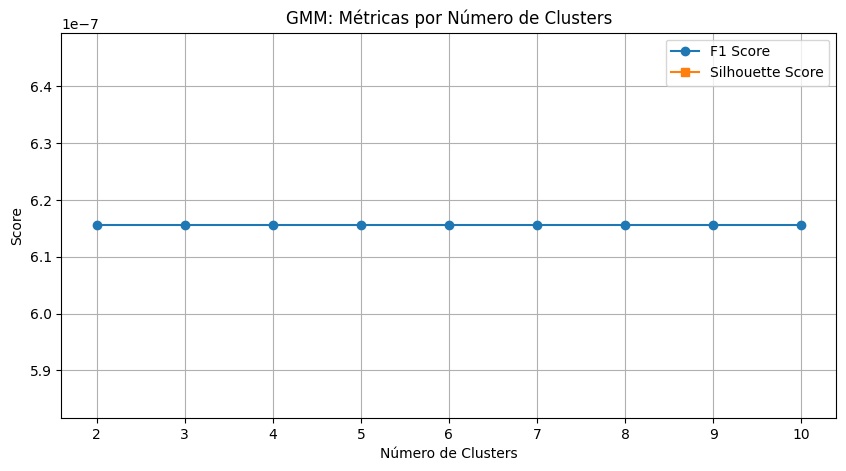

In [33]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import f1_score, silhouette_score
import pandas as pd

results = []

for proj_file in proj_files:
    print(f"\nGMM: processando {proj_file}")
    data = np.load(proj_file)
    
    for n_clusters in cluster_range:
        model = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
        cluster_labels = model.fit_predict(data)
        
        f1 = f1_score(numeric_labels, cluster_labels, average='macro')
        silhouette = silhouette_score(data, cluster_labels) if len(np.unique(cluster_labels)) > 1 else float('nan')
        
        results.append({
            'n_clusters': n_clusters,
            'f1_score': f1,
            'silhouette_score': silhouette
        })

df = pd.DataFrame(results)
print(df)

plt.figure(figsize=(10,5))
plt.plot(df['n_clusters'], df['f1_score'], marker='o', label='F1 Score')
plt.plot(df['n_clusters'], df['silhouette_score'], marker='s', label='Silhouette Score')
plt.title('GMM: Métricas por Número de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()
